### Importing

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift , KMeans , estimate_bandwidth

### Making Sample Data

In [9]:
X1 , _ = make_blobs(n_samples = 300 , centers = [(-5 , 5)] , cluster_std = 1.0 , random_state = 101)
X2 , _ = make_blobs(n_samples = 150 , centers = [(0 , 0)] , cluster_std = 0.5 , random_state = 101)
X3 , _ = make_blobs(n_samples = 400 , centers = [(5 , 5)] , cluster_std = 1.2 , random_state = 101)
X4 , _ = make_blobs(n_samples = 150 , centers = [(5 , -5)] , cluster_std = 0.4 , random_state = 101)

data = np.vstack([X1 , X2 , X3 , X4])

### Scatter Plot 

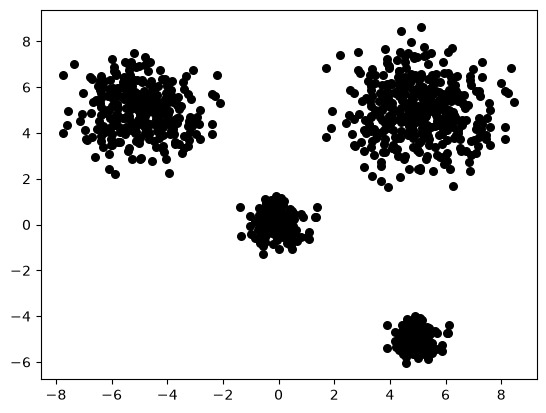

In [10]:
plt.scatter(data[: , 0] , data[: , 1] , s = 30 , color = "black")
plt.show()

### Elbow Method(KMeans)

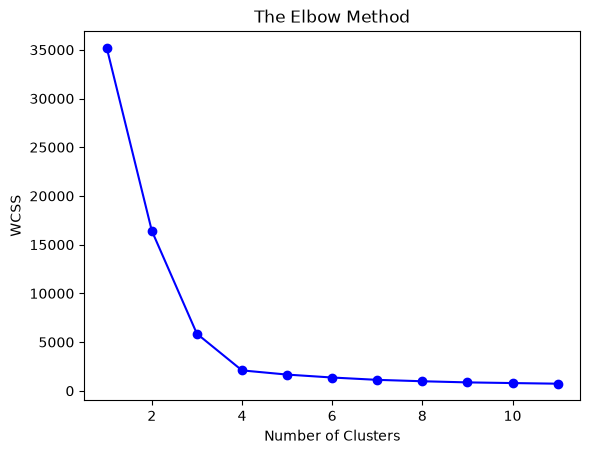

In [13]:
wcss = []

for i in range(1 , 12):
    model = KMeans(n_clusters = i , init = "k-means++" , max_iter = 300 , n_init = 10)
    model.fit_predict(data)
    wcss.append(model.inertia_)

plt.plot(range(1 , 12) , wcss , "bo-")
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Train Model & Visualize Clusters

In [15]:
bandwidth = estimate_bandwidth(data , quantile = 0.25)
final_model = MeanShift(bandwidth = bandwidth)
result = final_model.fit_predict(data)
np.unique(result)

array([0, 1, 2, 3])

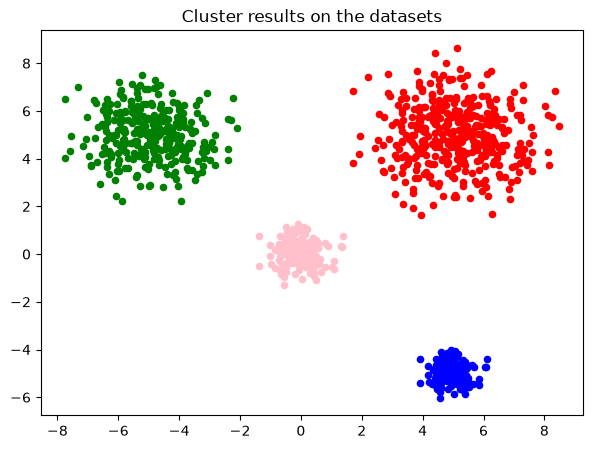

In [16]:
plt.figure(figsize = (7 , 5))
plt.scatter(data[result == 0 , 0] , data[result == 0 , 1] , s = 20 , c = "red")
plt.scatter(data[result == 1 , 0] , data[result == 1 , 1] , s = 20 , c = "green")
plt.scatter(data[result == 2 , 0] , data[result == 2 , 1] , s = 20 , c = "blue")
plt.scatter(data[result == 3 , 0] , data[result == 3 , 1] , s = 20 , c = "pink")

plt.title("Cluster results on the datasets")
plt.show()